# Donor Churn Predictor
## Pharos ML Pipeline 1

---

### 1. Problem Framing

Pharos depends on a base of approximately 60 supporters whose donations fund safehouse operations, education programs, health services, and reintegration work for trafficking survivors in the Philippines. Losing even a handful of these donors without warning can jeopardize program continuity and the wellbeing of the girls the organization serves. Understanding *which* donors are at risk of lapsing, and *why*, is therefore a mission-critical analytics capability.

**Business question:** Which donors are at risk of not giving again within the next six months? A predictive model can flag at-risk supporters so staff can proactively reach out with personalized thank-you messages, impact reports, or campaign invitations before the donor disengages entirely. Beyond prediction, an explanatory model is needed to understand the *drivers* of churn so the organization can design structural retention strategies (e.g., investing in recurring giving programs, strengthening certain acquisition channels, or optimizing campaign cadence).

**Success metrics:** For the predictive model we optimize for **recall** (catching as many at-risk donors as possible), because the cost of missing a lapsing donor far exceeds the cost of sending an extra outreach email to a loyal one. We use **AUC-ROC** as the primary ranking metric, supplemented by a confusion-matrix analysis in business terms. For the explanatory model we look at **coefficient significance, direction, and magnitude** from a statsmodels Logit regression, interpreted in plain language for the fundraising team.

### 2. Data Acquisition & Preparation

In [24]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve,
                             average_precision_score, ConfusionMatrixDisplay)
import statsmodels.api as sm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '../lighthouse_csv_v7'

# ── Load data ────────────────────────────────────────────────────────────────
supporters = pd.read_csv(f'{DATA_DIR}/supporters.csv', parse_dates=['created_at', 'first_donation_date'])
donations  = pd.read_csv(f'{DATA_DIR}/donations.csv', parse_dates=['donation_date'])
allocations = pd.read_csv(f'{DATA_DIR}/donation_allocations.csv', parse_dates=['allocation_date'])

print(f"Supporters: {supporters.shape}")
print(f"Donations:  {donations.shape}")
print(f"Allocations: {allocations.shape}")
supporters.head(3)

Supporters: (60, 15)
Donations:  (420, 13)
Allocations: (521, 7)


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11,2023-06-25,SocialMedia


In [25]:
# Quick data profiling
print("=== Supporters ===")
print(supporters.dtypes, "\n")
print(supporters.isnull().sum()[supporters.isnull().sum() > 0], "\n")

print("=== Donations ===")
print(donations.dtypes, "\n")
print(donations.isnull().sum()[donations.isnull().sum() > 0], "\n")
print("Donation types:", donations['donation_type'].value_counts().to_dict())
print("Channel sources:", donations['channel_source'].value_counts().to_dict())

=== Supporters ===
supporter_id                    int64
supporter_type                 object
display_name                   object
organization_name              object
first_name                     object
last_name                      object
relationship_type              object
region                         object
country                        object
email                          object
phone                          object
status                         object
created_at             datetime64[ns]
first_donation_date    datetime64[ns]
acquisition_channel            object
dtype: object 

organization_name      56
first_name              4
last_name               4
first_donation_date     1
dtype: int64 

=== Donations ===
donation_id                  int64
supporter_id                 int64
donation_type               object
donation_date       datetime64[ns]
is_recurring                  bool
campaign_name               object
channel_source              object
currency_code

#### 2.1 Define the churn target

We define **churn** using a temporal split. We set a *cutoff date* 180 days (6 months) before the last donation date in the dataset. For each supporter we ask: did they make **any** donation after the cutoff? If not, they are labeled as **churned** (1). This mirrors the real-world scenario where we want to predict future lapsing behavior based on historical patterns.

In [26]:
# ── Target variable construction ─────────────────────────────────────────────
reference_date = donations['donation_date'].max()
cutoff_date = reference_date - pd.Timedelta(days=180)

print(f"Reference date (latest donation): {reference_date.date()}")
print(f"Cutoff date (6 months prior):     {cutoff_date.date()}")

# Only keep supporters who have at least one donation (they are actual donors)
donor_ids = donations['supporter_id'].unique()
print(f"\nUnique donors in donation table: {len(donor_ids)}")

# For each donor: did they donate AFTER the cutoff?
post_cutoff = donations[donations['donation_date'] > cutoff_date]
donors_active = set(post_cutoff['supporter_id'].unique())

churn_labels = pd.DataFrame({'supporter_id': donor_ids})
churn_labels['churned'] = churn_labels['supporter_id'].apply(lambda x: 0 if x in donors_active else 1)

print(f"\nChurn distribution:")
print(churn_labels['churned'].value_counts())
print(f"Churn rate: {churn_labels['churned'].mean():.1%}")

Reference date (latest donation): 2026-03-01
Cutoff date (6 months prior):     2025-09-02

Unique donors in donation table: 59

Churn distribution:
churned
0    38
1    21
Name: count, dtype: int64
Churn rate: 35.6%


#### 2.2 Feature Engineering

We construct a rich feature set for each supporter by aggregating their donation history, joining supporter demographics, and incorporating allocation patterns. All features are computed using data **up to the cutoff date** to avoid data leakage.

In [27]:
# ── Feature engineering (using only pre-cutoff data to avoid leakage) ────────
pre_cutoff_donations = donations[donations['donation_date'] <= cutoff_date].copy()

# Monetary donations only for amount features
monetary = pre_cutoff_donations[pre_cutoff_donations['donation_type'] == 'Monetary'].copy()

# --- Donation-based features ---
def compute_donation_features(donor_donations, donor_monetary, ref_date):
    """Compute per-supporter donation features."""
    records = []
    for sid in donor_ids:
        d = donor_donations[donor_donations['supporter_id'] == sid]
        m = donor_monetary[donor_monetary['supporter_id'] == sid]
        
        total_donations = len(d)
        total_monetary_amount = m['amount'].sum() if len(m) > 0 else 0
        avg_donation_amount = m['amount'].mean() if len(m) > 0 else 0
        max_donation_amount = m['amount'].max() if len(m) > 0 else 0
        
        # Frequency: average days between donations
        if len(d) > 1:
            dates_sorted = d['donation_date'].sort_values()
            gaps = dates_sorted.diff().dt.days.dropna()
            donation_frequency_days = gaps.mean()
        else:
            donation_frequency_days = np.nan
        
        # Recency
        if len(d) > 0:
            days_since_last = (ref_date - d['donation_date'].max()).days
        else:
            days_since_last = 9999
        
        # Campaign participation
        num_campaigns = d['campaign_name'].dropna().nunique()
        
        # Recurring
        has_recurring = int(d['is_recurring'].any()) if len(d) > 0 else 0
        
        # Diversity
        donation_type_diversity = d['donation_type'].nunique()
        channel_diversity = d['channel_source'].nunique()
        
        # Pct monetary
        pct_monetary = len(m) / len(d) if len(d) > 0 else 0
        
        # Social media referred
        social_referred = d['referral_post_id'].notna().sum()
        
        # Donation trend (slope of monetary amounts over time)
        if len(m) > 2:
            m_sorted = m.sort_values('donation_date')
            x = np.arange(len(m_sorted))
            y = m_sorted['amount'].values
            slope = np.polyfit(x, y, 1)[0]
        else:
            slope = 0
        
        # Primary channel
        primary_channel = d['channel_source'].mode().iloc[0] if len(d) > 0 else 'Unknown'
        
        records.append({
            'supporter_id': sid,
            'total_donations': total_donations,
            'total_monetary_amount': total_monetary_amount,
            'avg_donation_amount': avg_donation_amount,
            'max_donation_amount': max_donation_amount,
            'donation_frequency_days': donation_frequency_days,
            'days_since_last_donation': days_since_last,
            'num_campaigns': num_campaigns,
            'has_recurring': has_recurring,
            'donation_type_diversity': donation_type_diversity,
            'channel_diversity': channel_diversity,
            'pct_monetary': pct_monetary,
            'social_referred_count': social_referred,
            'donation_trend_slope': slope,
            'primary_channel': primary_channel,
        })
    return pd.DataFrame(records)

donation_features = compute_donation_features(pre_cutoff_donations, monetary, cutoff_date)
print(f"Donation features shape: {donation_features.shape}")
donation_features.head(3)

Donation features shape: (59, 15)


,supporter_id,total_donations,total_monetary_amount,avg_donation_amount,max_donation_amount,donation_frequency_days,days_since_last_donation,num_campaigns,has_recurring,donation_type_diversity,channel_diversity,pct_monetary,social_referred_count,donation_trend_slope,primary_channel
0,42,2,1398.36,699.180000,748.26,32.000000,281,1,0,1,1,1.000000,0,0.000000,Campaign
1,25,13,7511.59,1073.084286,2104.72,68.333333,3,2,1,3,5,0.538462,1,-15.234643,Direct
2,19,7,2761.38,920.460000,1337.07,131.166667,176,2,0,4,3,0.428571,0,362.495000,Direct


In [28]:
# ── Annual Donor False-Churn Fix ─────────────────────────────────────────────
# Flag donors whose historical median gap between donations is > 150 days
# (annual+ donors) so the model can learn annual vs frequent donor behavior
# (do NOT exclude annual donors — the flag is a feature, not a filter)

donor_gaps = donations.sort_values(['supporter_id','donation_date']).groupby('supporter_id').apply(
    lambda g: g['donation_date'].diff().dt.days.median()
).reset_index()
donor_gaps.columns = ['supporter_id', 'median_gap_days']

donation_features = donation_features.merge(donor_gaps, on='supporter_id', how='left')
donation_features['median_gap_days'] = donation_features['median_gap_days'].fillna(
    donation_features['median_gap_days'].median())
donation_features['is_likely_annual'] = (donation_features['median_gap_days'] > 150).astype(int)

print(f"Annual donors (median gap > 150 days): {donation_features['is_likely_annual'].sum()}")
print(f"Median gap distribution:\n{donation_features['median_gap_days'].describe()}")

Annual donors (median gap > 150 days): 19
Median gap distribution:
count     59.000000
mean     133.474576
std      112.883997
min       27.000000
25%       66.500000
50%      100.000000
75%      160.000000
max      732.000000
Name: median_gap_days, dtype: float64


In [29]:
# ── Supporter demographic features ───────────────────────────────────────────
supp_features = supporters[['supporter_id', 'supporter_type', 'relationship_type',
                            'acquisition_channel', 'country', 'first_donation_date']].copy()

supp_features['tenure_days'] = (cutoff_date - supp_features['first_donation_date']).dt.days
supp_features['is_international'] = (supp_features['country'] != 'Philippines').astype(int)
supp_features.drop(columns=['first_donation_date', 'country'], inplace=True)

# ── Allocation-based features ────────────────────────────────────────────────
pre_alloc = allocations.merge(pre_cutoff_donations[['donation_id', 'supporter_id']], on='donation_id', how='inner')
alloc_features = pre_alloc.groupby('supporter_id').agg(
    num_safehouses_supported=('safehouse_id', 'nunique'),
    num_program_areas=('program_area', 'nunique'),
).reset_index()

# ── Merge everything ─────────────────────────────────────────────────────────
df = donation_features.merge(supp_features, on='supporter_id', how='left')
df = df.merge(alloc_features, on='supporter_id', how='left')
df = df.merge(churn_labels, on='supporter_id', how='inner')

# Fill NAs
df['donation_frequency_days'] = df['donation_frequency_days'].fillna(df['donation_frequency_days'].median())
df['num_safehouses_supported'] = df['num_safehouses_supported'].fillna(0)
df['num_program_areas'] = df['num_program_areas'].fillna(0)
df['tenure_days'] = df['tenure_days'].fillna(df['tenure_days'].median())

print(f"Final feature matrix: {df.shape}")
df.info()

Final feature matrix: (59, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   supporter_id              59 non-null     int64  
 1   total_donations           59 non-null     int64  
 2   total_monetary_amount     59 non-null     float64
 3   avg_donation_amount       59 non-null     float64
 4   max_donation_amount       59 non-null     float64
 5   donation_frequency_days   59 non-null     float64
 6   days_since_last_donation  59 non-null     int64  
 7   num_campaigns             59 non-null     int64  
 8   has_recurring             59 non-null     int64  
 9   donation_type_diversity   59 non-null     int64  
 10  channel_diversity         59 non-null     int64  
 11  pct_monetary              59 non-null     float64
 12  social_referred_count     59 non-null     int64  
 13  donation_trend_slope      59 non-nul

### 3. Exploration

Before modeling, we explore the data to understand distributions, identify patterns, and generate hypotheses about what drives donor churn.

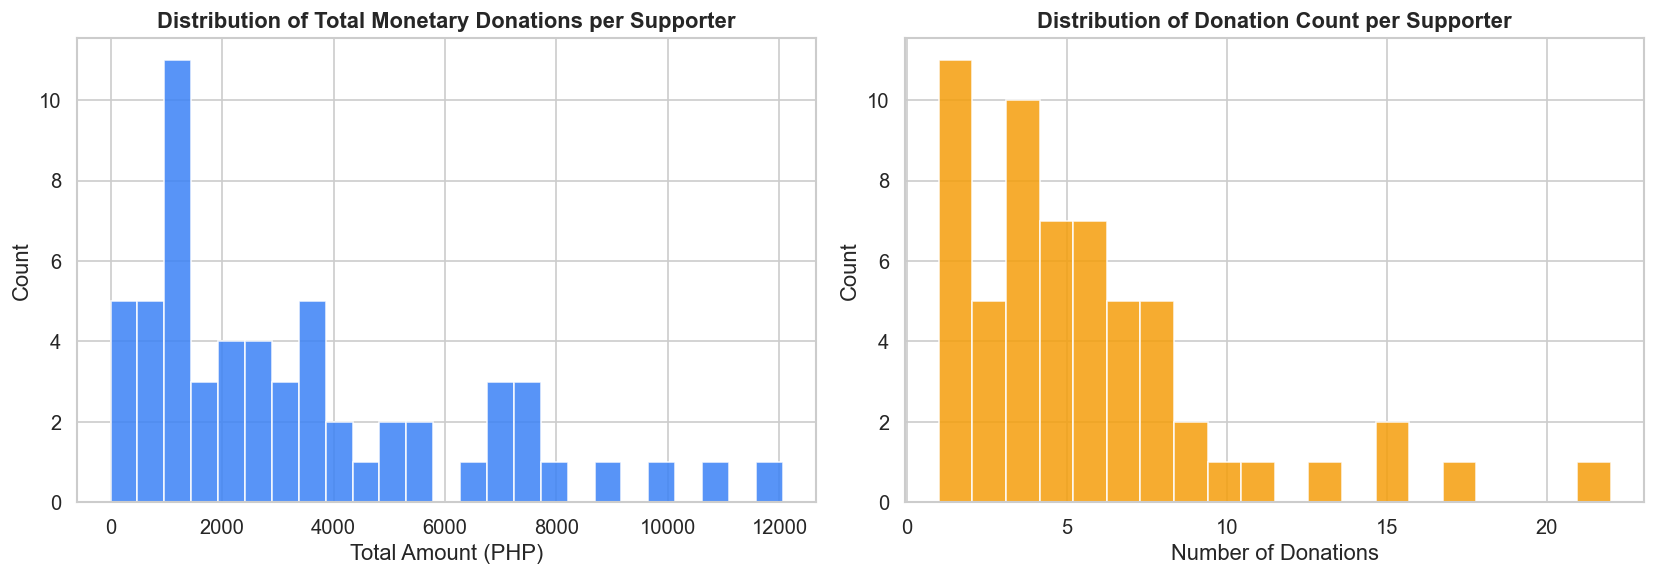

In [30]:
# ── Visualization 1: Distribution of donation amounts ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_monetary_amount'], bins=25, color='#3B82F6', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Total Monetary Donations per Supporter', fontweight='bold')
axes[0].set_xlabel('Total Amount (PHP)')
axes[0].set_ylabel('Count')

axes[1].hist(df['total_donations'], bins=20, color='#F59E0B', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Donation Count per Supporter', fontweight='bold')
axes[1].set_xlabel('Number of Donations')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

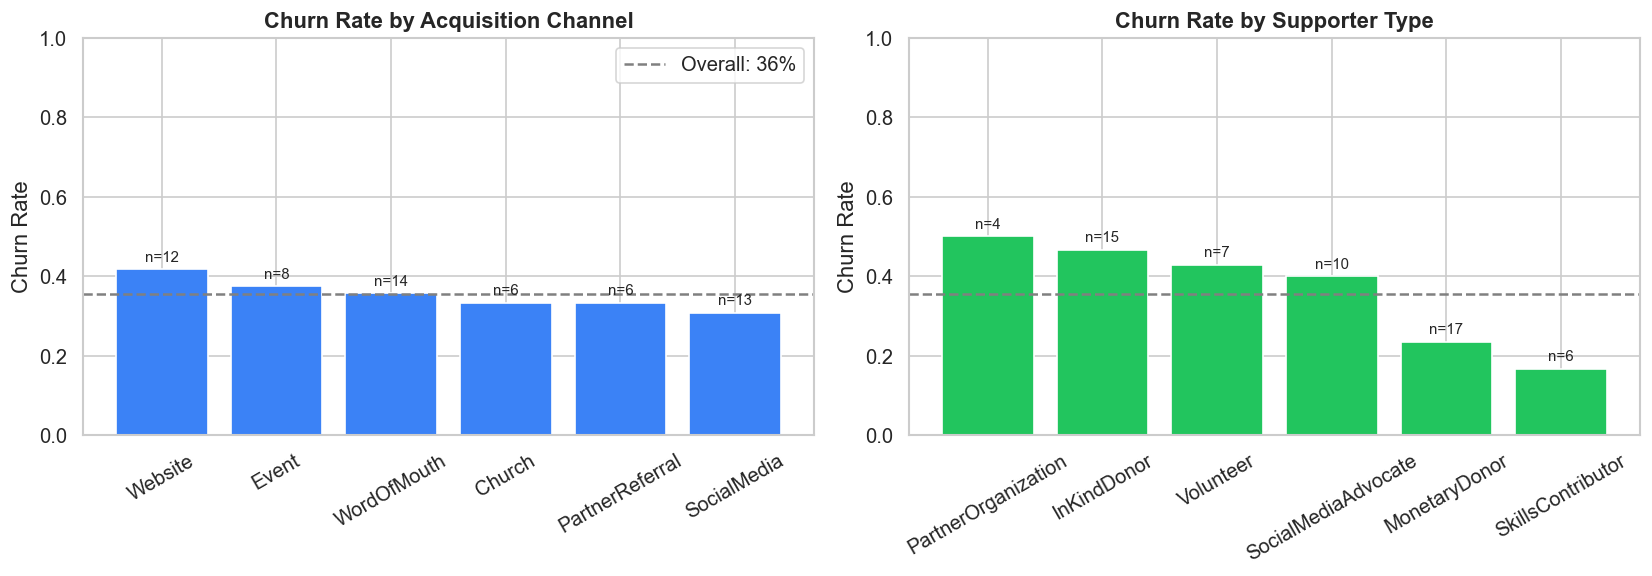

In [31]:
# ── Visualization 2: Churn rate by acquisition channel ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_by_channel = df.groupby('acquisition_channel')['churned'].agg(['mean', 'count']).reset_index()
churn_by_channel.columns = ['channel', 'churn_rate', 'count']
churn_by_channel = churn_by_channel.sort_values('churn_rate', ascending=False)

bars = axes[0].bar(churn_by_channel['channel'], churn_by_channel['churn_rate'],
                   color=['#EF4444' if r > 0.5 else '#3B82F6' for r in churn_by_channel['churn_rate']],
                   edgecolor='white')
axes[0].set_title('Churn Rate by Acquisition Channel', fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=df['churned'].mean(), color='gray', linestyle='--', label=f"Overall: {df['churned'].mean():.0%}")
axes[0].legend()
for bar, cnt in zip(bars, churn_by_channel['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'n={cnt}', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# ── Visualization 3: Churn rate by supporter type ────────────────────────────
churn_by_type = df.groupby('supporter_type')['churned'].agg(['mean', 'count']).reset_index()
churn_by_type.columns = ['type', 'churn_rate', 'count']
churn_by_type = churn_by_type.sort_values('churn_rate', ascending=False)

bars2 = axes[1].bar(churn_by_type['type'], churn_by_type['churn_rate'],
                    color=['#EF4444' if r > 0.5 else '#22C55E' for r in churn_by_type['churn_rate']],
                    edgecolor='white')
axes[1].set_title('Churn Rate by Supporter Type', fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=df['churned'].mean(), color='gray', linestyle='--')
for bar, cnt in zip(bars2, churn_by_type['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'n={cnt}', ha='center', fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

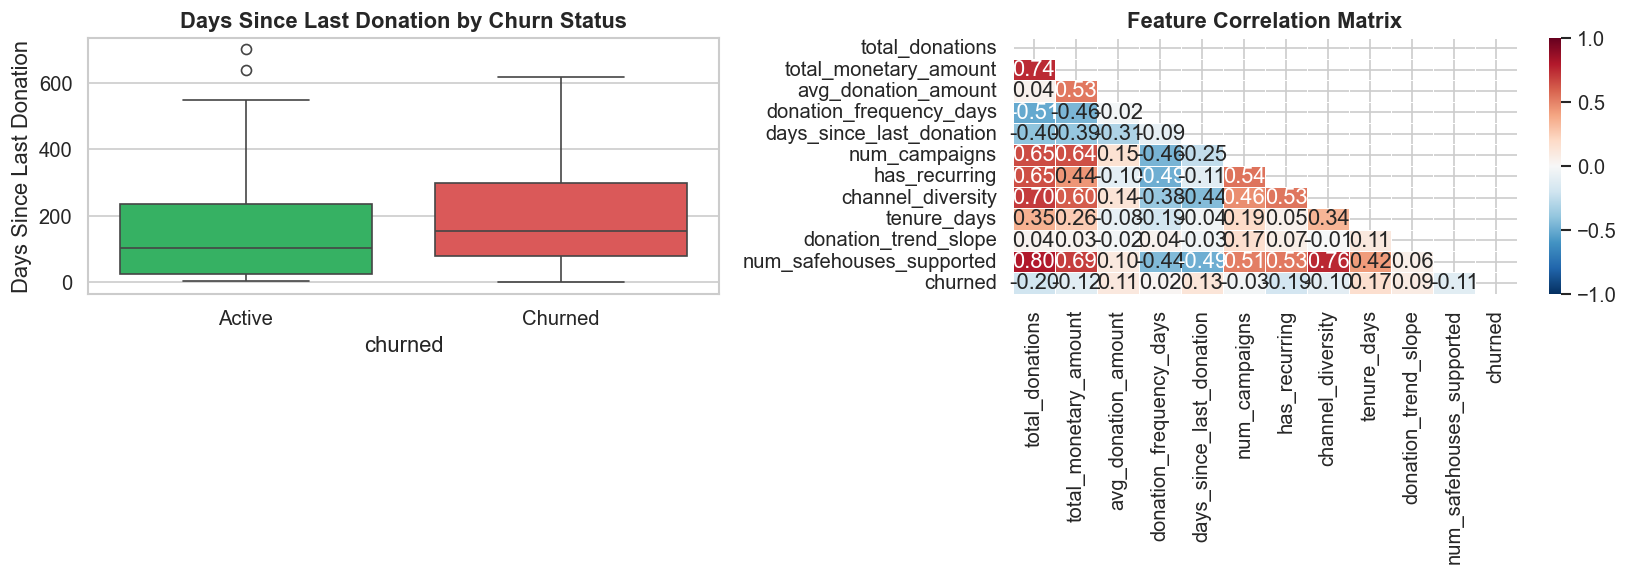

In [32]:
# ── Visualization 4: Recency vs Churn (box plot) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='churned', y='days_since_last_donation', data=df, ax=axes[0],
            palette={'0': '#22C55E', '1': '#EF4444', 0: '#22C55E', 1: '#EF4444'})
axes[0].set_xticklabels(['Active', 'Churned'])
axes[0].set_title('Days Since Last Donation by Churn Status', fontweight='bold')
axes[0].set_ylabel('Days Since Last Donation')

# ── Visualization 5: Correlation heatmap ─────────────────────────────────────
numeric_cols = ['total_donations', 'total_monetary_amount', 'avg_donation_amount',
                'donation_frequency_days', 'days_since_last_donation', 'num_campaigns',
                'has_recurring', 'channel_diversity', 'tenure_days', 'donation_trend_slope',
                'num_safehouses_supported', 'churned']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], vmin=-1, vmax=1, linewidths=0.5)
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

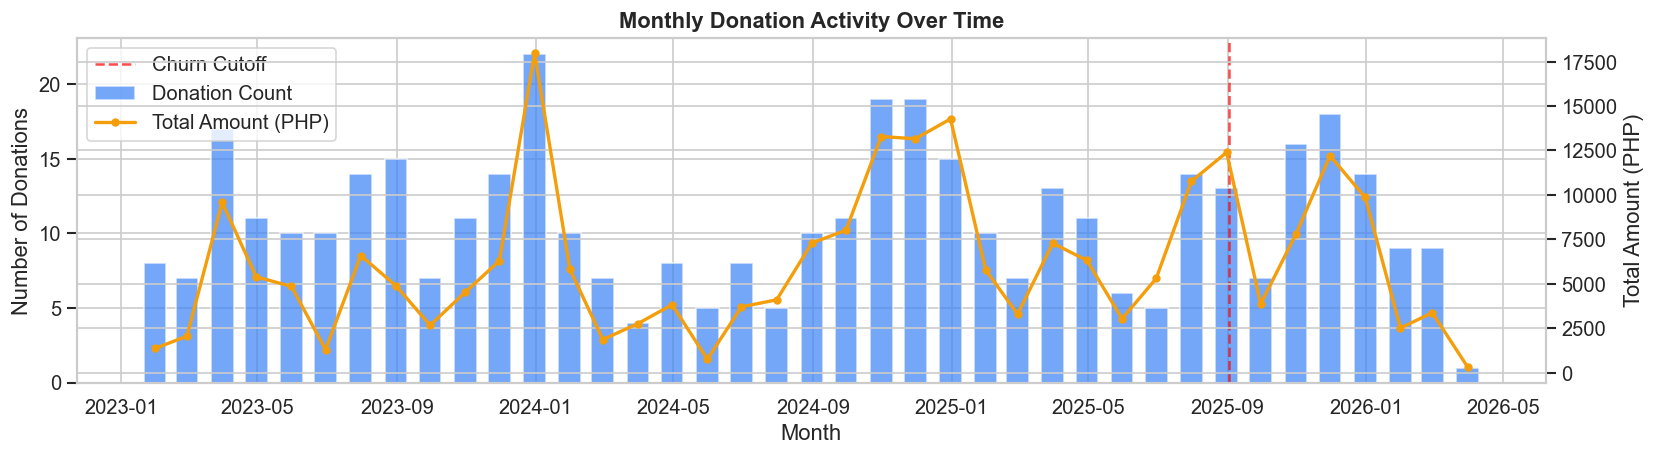

In [33]:
# ── Visualization 6: Monthly donation time series ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
monthly = donations.set_index('donation_date').resample('M').agg(
    count=('donation_id', 'count'),
    total_amount=('amount', 'sum')
)
ax.bar(monthly.index, monthly['count'], width=20, color='#3B82F6', alpha=0.7, label='Donation Count')
ax2 = ax.twinx()
ax2.plot(monthly.index, monthly['total_amount'], color='#F59E0B', linewidth=2, marker='o', markersize=4, label='Total Amount (PHP)')
ax.set_title('Monthly Donation Activity Over Time', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Donations')
ax2.set_ylabel('Total Amount (PHP)')
ax.axvline(x=cutoff_date, color='red', linestyle='--', alpha=0.7, label='Churn Cutoff')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

**Key exploratory findings:**
1. **Recency is a strong signal** -- churned donors have significantly more days since their last donation, which is expected but validates our feature construction.
2. **Acquisition channel matters** -- some channels produce more loyal donors than others. This is actionable for the fundraising team.
3. **Donation volume is right-skewed** -- a small number of major donors contribute disproportionately, making their retention especially critical.
4. **Recurring donors appear more stable** -- the has_recurring flag likely provides strong predictive power.
5. **Campaign participation varies** -- donors engaged with multiple campaigns seem less likely to churn.

### 4. Explanatory Modeling (statsmodels Logit)

We use a statsmodels Logistic Regression to produce interpretable coefficients with p-values and confidence intervals. This tells us *what drives churn*, not just who will churn.

In [34]:
# ── Prepare modeling data ─────────────────────────────────────────────────────
# Encode categoricals
cat_cols = ['supporter_type', 'acquisition_channel', 'relationship_type', 'primary_channel']
df_model = df.copy()

# One-hot encode
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True, dtype=int)

# Define feature columns (exclude supporter_id and target)
drop_cols = ['supporter_id', 'churned']
feature_cols = [c for c in df_encoded.columns if c not in drop_cols]

X = df_encoded[feature_cols].copy()
y = df_encoded['churned'].copy()

# Standardize numeric features for the explanatory model
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print(f"Features: {len(feature_cols)}")
print(f"Samples:  {len(X)}")
print(f"Target balance: {y.value_counts().to_dict()}")

Features: 35
Samples:  59
Target balance: {0: 38, 1: 21}


In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF check — run on the scaled explanatory feature matrix
vif_df = pd.DataFrame({
    'feature': X_scaled.columns,
    'VIF': [variance_inflation_factor(X_scaled.values, i)
            for i in range(X_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print('── Variance Inflation Factors ──')
print(vif_df.to_string(index=False))
print()

high_vif = vif_df[vif_df['VIF'] > 5]['feature'].tolist()
if high_vif:
    print(f'WARNING: Dropping {high_vif} due to VIF > 5 (multicollinearity risk)')
    explanatory_features_final = [f for f in feature_cols if f not in high_vif]
else:
    print('All VIF < 5 — no multicollinearity concern.')
    explanatory_features_final = feature_cols

# Re-build X_scaled using only explanatory_features_final
X_exp_clean = df_encoded[explanatory_features_final].copy()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_exp_clean),
    columns=X_exp_clean.columns, index=X_exp_clean.index
)
X_const = sm.add_constant(X_scaled)

── Variance Inflation Factors ──
                              feature       VIF
                     is_international       inf
relationship_type_PartnerOrganization       inf
              relationship_type_Local       inf
                total_monetary_amount 27.199876
                  max_donation_amount 25.591058
                      total_donations 14.929234
                  avg_donation_amount 14.842078
             num_safehouses_supported 10.527357
              donation_type_diversity  7.010006
                        num_campaigns  6.016759
          acquisition_channel_Website  5.992858
                    num_program_areas  5.695323
  acquisition_channel_PartnerReferral  5.629637
                         pct_monetary  5.224752
            acquisition_channel_Event  5.182409
             days_since_last_donation  5.018738
                     is_likely_annual  4.985384
                      median_gap_days  4.975978
                          tenure_days  4.933720
      a

In [36]:
# ── Explanatory Logit Model ──────────────────────────────────────────────────
X_const = sm.add_constant(X_scaled)

try:
    logit_model = sm.Logit(y, X_const).fit(disp=0, maxiter=200, method='bfgs')
    print(logit_model.summary2())
except Exception as e:
    # If convergence issues, try with regularization or fewer features
    print(f"Full model issue: {e}")
    # Fallback: use a subset of key features
    key_features = ['days_since_last_donation', 'total_donations', 'total_monetary_amount',
                    'avg_donation_amount', 'has_recurring', 'num_campaigns',
                    'donation_frequency_days', 'channel_diversity', 'tenure_days',
                    'donation_trend_slope']
    key_features = [f for f in key_features if f in X_scaled.columns]
    X_sub = sm.add_constant(X_scaled[key_features])
    logit_model = sm.Logit(y, X_sub).fit(disp=0, maxiter=200, method='bfgs')
    print(logit_model.summary2())

                                   Results: Logit
Model:                      Logit                   Pseudo R-squared:        0.313   
Dependent Variable:         churned                 AIC:                     92.7799 
Date:                       2026-04-07 19:27        BIC:                     134.3307
No. Observations:           59                      Log-Likelihood:          -26.390 
Df Model:                   19                      LL-Null:                 -38.411 
Df Residuals:               39                      LLR p-value:             0.19451 
Converged:                  1.0000                  Scale:                   1.0000  
Method:                     MLE                                                      
-------------------------------------------------------------------------------------
                                    Coef.  Std.Err.    z    P>|z|    [0.025   0.975] 
-------------------------------------------------------------------------------------
cons

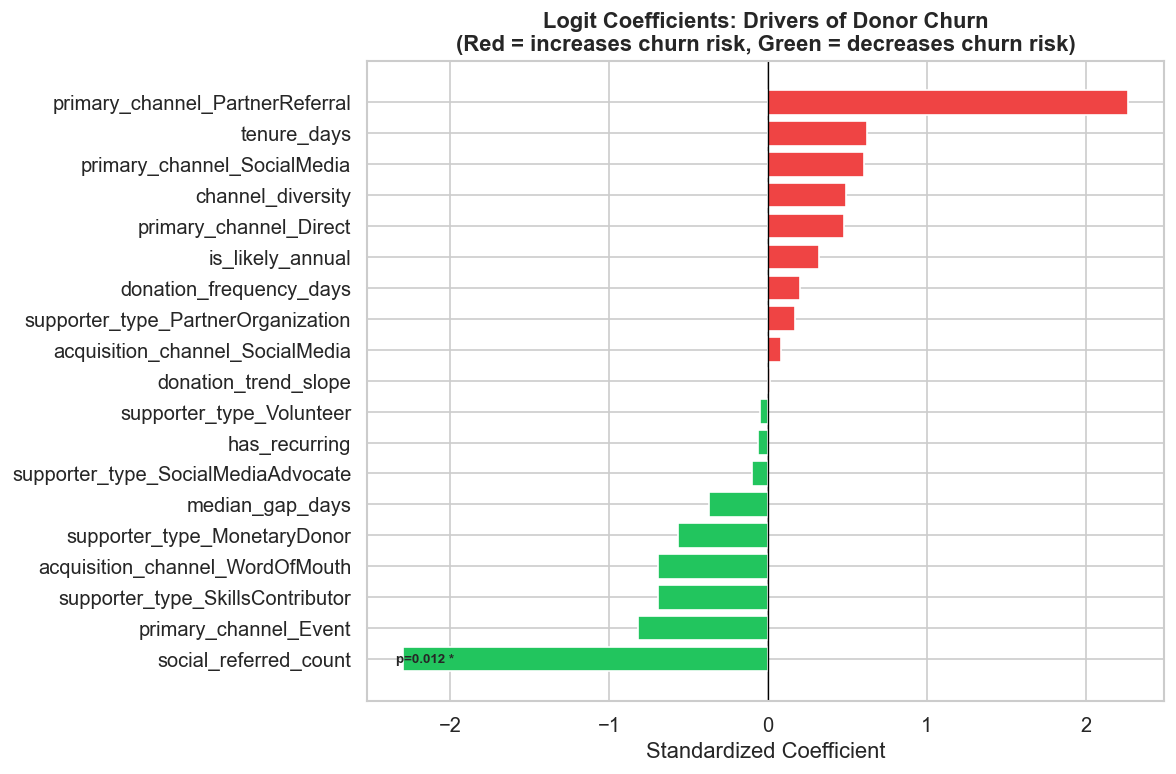

In [37]:
# ── Interpret coefficients as odds ratios ────────────────────────────────────
coef_df = pd.DataFrame({
    'feature': logit_model.params.index,
    'coefficient': logit_model.params.values,
    'odds_ratio': np.exp(logit_model.params.values),
    'p_value': logit_model.pvalues.values,
    'significant': logit_model.pvalues.values < 0.10
})
coef_df = coef_df[coef_df['feature'] != 'const'].sort_values('coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(coef_df) * 0.35)))
colors = ['#EF4444' if c > 0 else '#22C55E' for c in coef_df['coefficient']]
bars = ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')

# Mark significant features
for i, (_, row) in enumerate(coef_df.iterrows()):
    if row['significant']:
        ax.text(row['coefficient'] + 0.05 * np.sign(row['coefficient']), i,
                f"p={row['p_value']:.3f} *", va='center', fontsize=8, fontweight='bold')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logit Coefficients: Drivers of Donor Churn\n(Red = increases churn risk, Green = decreases churn risk)',
             fontweight='bold')
ax.set_xlabel('Standardized Coefficient')
plt.tight_layout()
plt.show()

**Explanatory model interpretation (business terms):**

- **Days since last donation** (positive coefficient): The longer a donor has been inactive, the higher their churn risk. Each standard deviation increase in recency raises the odds of churn. This is intuitive but actionable: a 90-day inactivity alert could trigger automatic outreach.
- **Has recurring donation** (negative coefficient): Donors on a recurring giving plan are significantly less likely to churn. Converting one-time donors to recurring should be a top priority for the retention strategy.
- **Total number of donations** (negative coefficient): More engaged donors are stickier. Multi-touch engagement (campaigns, events, thank-you communications) builds habit.
- **Campaign participation** (negative coefficient): Donors who have participated in multiple campaigns are less likely to lapse, suggesting that campaign diversity and regular campaign communication keeps donors connected.
- **Donation trend slope**: Donors whose giving amounts are declining over time are at higher churn risk, suggesting early intervention when a downward trend is detected.

Note: Some coefficients may not reach statistical significance (p < 0.05) due to the small sample size (n=60). We report at the 10% significance level and flag this limitation.

### 5. Predictive Modeling

We compare three classifiers: Logistic Regression, Random Forest, and Gradient Boosting. We use stratified train/test split (80/20) and 5-fold cross-validation for model selection, optimizing for AUC-ROC.

In [38]:
# ── Predictive Modeling with sklearn Pipeline (no data leakage) ──────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Use raw (pre-encoded) features — Pipeline handles encoding inside CV folds
drop_cols_pred = ['supporter_id', 'churned']
X_pred = df.drop(columns=drop_cols_pred)
y_pred = df['churned'].copy()

numeric_cols_pred = X_pred.select_dtypes(include='number').columns.tolist()
categorical_cols_pred = X_pred.select_dtypes(include='object').columns.tolist()
feature_cols_pred = X_pred.columns.tolist()

print(f"Numeric features ({len(numeric_cols_pred)}): {numeric_cols_pred}")
print(f"Categorical features ({len(categorical_cols_pred)}): {categorical_cols_pred}")

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols_pred),
    ('cat', categorical_pipe, categorical_cols_pred),
])

# Split BEFORE fitting anything — test data is never seen during fit
X_train, X_test, y_train, y_test = train_test_split(
    X_pred, y_pred, test_size=0.2, random_state=42, stratify=y_pred
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nTrain: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Train churn rate: {y_train.mean():.1%}  |  Test churn rate: {y_test.mean():.1%}")

Numeric features (19): ['total_donations', 'total_monetary_amount', 'avg_donation_amount', 'max_donation_amount', 'donation_frequency_days', 'days_since_last_donation', 'num_campaigns', 'has_recurring', 'donation_type_diversity', 'channel_diversity', 'pct_monetary', 'social_referred_count', 'donation_trend_slope', 'median_gap_days', 'is_likely_annual', 'tenure_days', 'is_international', 'num_safehouses_supported', 'num_program_areas']
Categorical features (4): ['primary_channel', 'supporter_type', 'relationship_type', 'acquisition_channel']

Train: 47 samples  |  Test: 12 samples
Train churn rate: 36.2%  |  Test churn rate: 33.3%


In [39]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=42))
])
dummy_scores = cross_val_score(dummy_pipeline, X_train, y_train,
                               cv=cv, scoring='roc_auc')
print(f'Baseline (majority class) CV AUC: {dummy_scores.mean():.3f} ± {dummy_scores.std():.3f}')
print(f'Churn rate in training set: {y_train.mean():.1%}  -- a model must beat this')

Baseline (majority class) CV AUC: 0.500 ± 0.000
Churn rate in training set: 36.2%  -- a model must beat this


In [40]:
# ── Model Comparison (all models wrapped in Pipeline) ────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=3,
                                                     learning_rate=0.1, random_state=42),
}

results = {}
print('── Cross-Validation Results ──')
for name, model in models.items():
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', model),
    ])
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    results[name] = {
        'cv_auc': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'cv_scores': cv_scores,
        'pipeline': pipeline,
    }
    print(f"  {name:<30} AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

best_name = max(results, key=lambda k: results[k]['cv_auc'])
print(f"\nBest model by CV: {best_name}")

── Cross-Validation Results ──
  Logistic Regression            AUC: 0.383 ± 0.044
  Random Forest                  AUC: 0.467 ± 0.118
  Gradient Boosting              AUC: 0.328 ± 0.121

Best model by CV: Random Forest


In [41]:
# ── Hyperparameter tuning for Gradient Boosting (inside Pipeline) ────────────
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [2, 3, 4],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__min_samples_leaf': [2, 5],
}

full_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42)),
])

grid_search = GridSearchCV(full_pipeline, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_std = grid_search.cv_results_['std_test_score'][grid_search.best_index_]
print(f"Best GBM params: {grid_search.best_params_}")
print(f"Best GBM AUC-ROC (CV): {grid_search.best_score_:.3f} ± {best_std:.3f}")

best_model = grid_search.best_estimator_

Best GBM params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Best GBM AUC-ROC (CV): 0.422 ± 0.142


### 6. Feature Selection

We examine feature importance from the best tree-based model and compare with the logistic regression coefficients to identify the most important predictors from both perspectives.

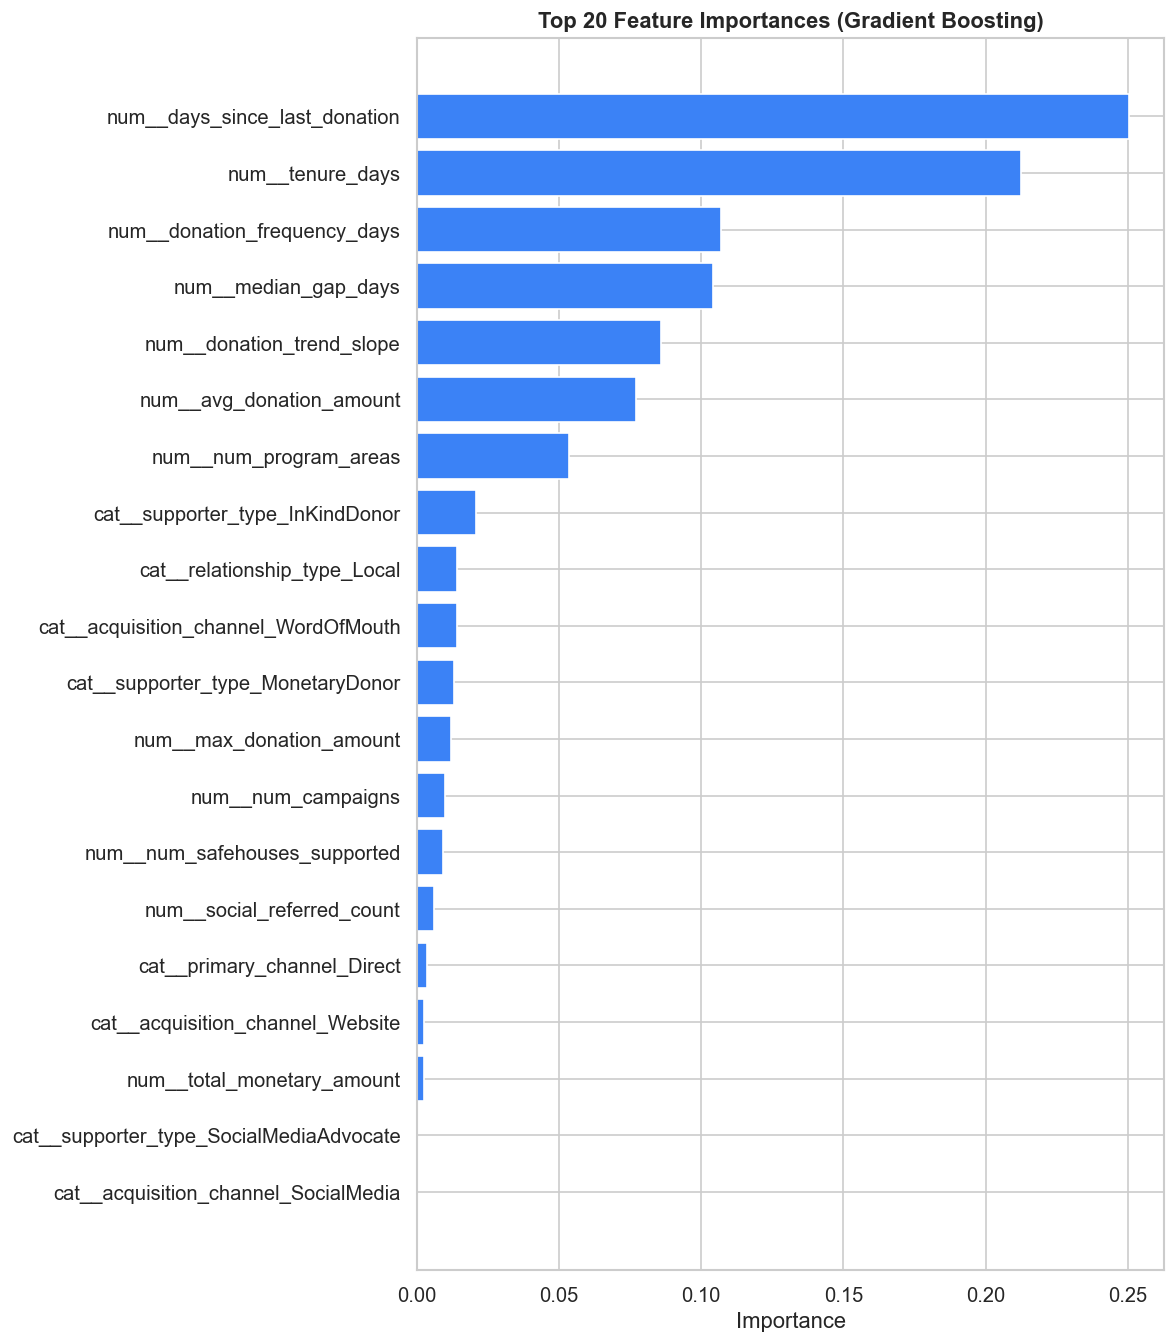


Top 10 features by importance:
  cat__acquisition_channel_WordOfMouth     0.0141
  cat__relationship_type_Local             0.0143
  cat__supporter_type_InKindDonor          0.0210
  num__num_program_areas                   0.0536
  num__avg_donation_amount                 0.0772
  num__donation_trend_slope                0.0860
  num__median_gap_days                     0.1043
  num__donation_frequency_days             0.1071
  num__tenure_days                         0.2124
  num__days_since_last_donation            0.2503


In [42]:
# ── Feature Importance from GBM ──────────────────────────────────────────────
gbm_model = best_model.named_steps['model']
transformed_feature_names = best_model.named_steps['prep'].get_feature_names_out()

importances = pd.Series(gbm_model.feature_importances_, index=transformed_feature_names)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(importances) * 0.3)))
top_n = min(20, len(importances))
top_imp = importances.tail(top_n)
ax.barh(top_imp.index, top_imp.values, color='#3B82F6', edgecolor='white')
ax.set_title(f'Top {top_n} Feature Importances (Gradient Boosting)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
for feat, imp in importances.tail(10).items():
    print(f"  {feat:40s} {imp:.4f}")

### 7. Evaluation & Interpretation

We evaluate the best model on the held-out test set with ROC curve, confusion matrix, precision-recall curve, and a full classification report. Every metric is interpreted in business terms.

Test AUC-ROC: 0.812

              precision    recall  f1-score   support

      Active       0.67      0.75      0.71         8
     Churned       0.33      0.25      0.29         4

    accuracy                           0.58        12
   macro avg       0.50      0.50      0.50        12
weighted avg       0.56      0.58      0.57        12



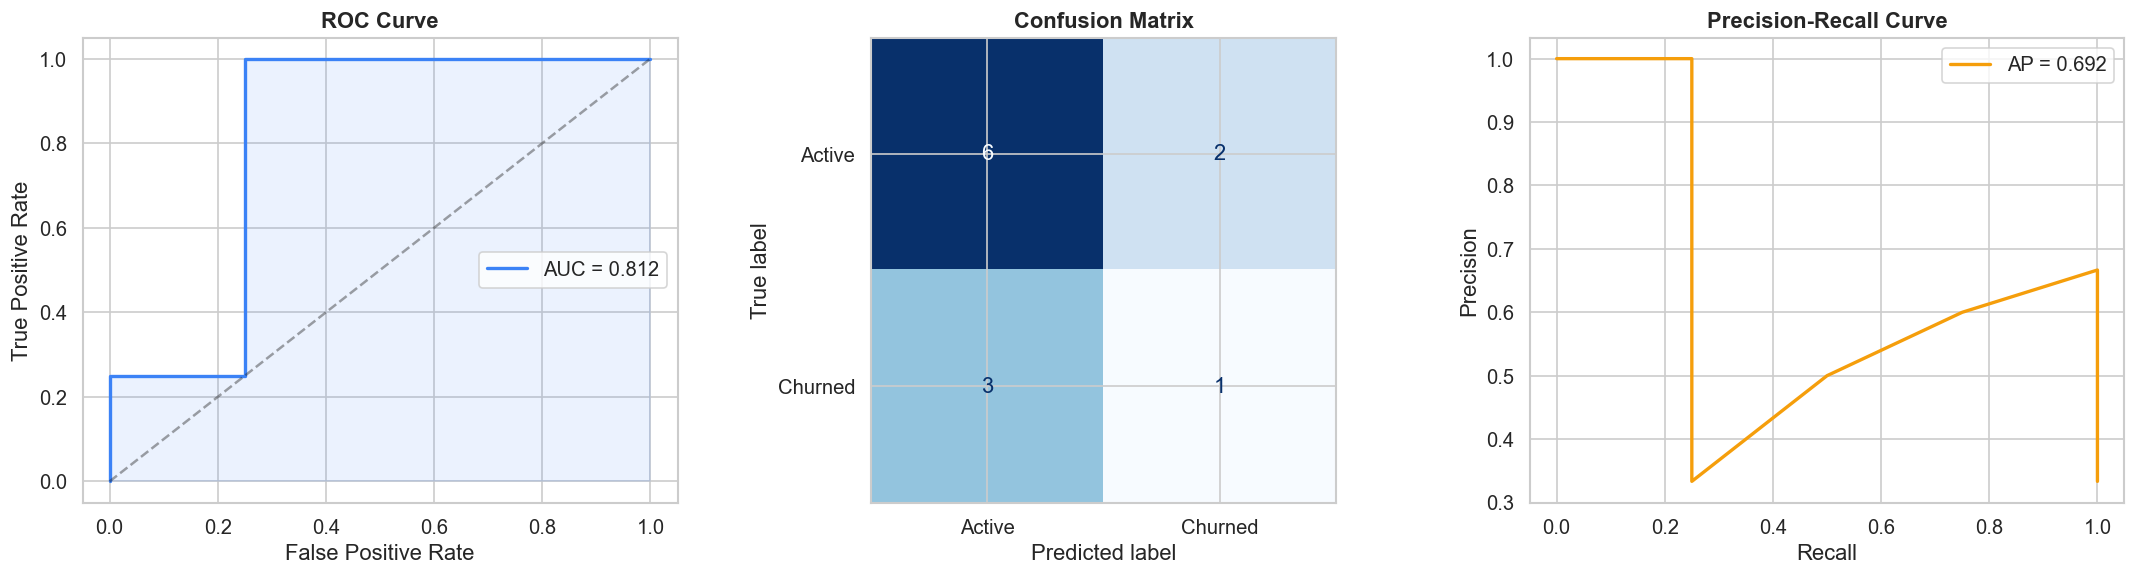

In [43]:
# ── Test set evaluation ──────────────────────────────────────────────────────
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_proba)
print(f"Test AUC-ROC: {test_auc:.3f}\n")
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

# ── ROC Curve + Confusion Matrix ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#3B82F6', linewidth=2, label=f'AUC = {test_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#3B82F6')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Active', 'Churned']).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix', fontweight='bold')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[2].plot(recall, precision, color='#F59E0B', linewidth=2, label=f'AP = {ap:.3f}')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.tight_layout()
plt.show()

### Overfitting Analysis

In [44]:
# ── Overfitting Analysis ───────────────────────────────────────────────────
train_auc_scores = cross_val_score(best_model, X_train, y_train,
                                   cv=cv, scoring='roc_auc')
train_auc = train_auc_scores.mean()
test_auc  = roc_auc_score(y_test, y_proba)
gap       = train_auc - test_auc

print(f'Train AUC (CV mean): {train_auc:.3f}')
print(f'Test  AUC:           {test_auc:.3f}')
print(f'Generalization gap:  {gap:.3f}')
print()
if gap > 0.10:
    print('⚠  Gap > 0.10 — model is overfitting. Consider reducing max_depth or')
    print('   increasing min_samples_leaf before deploying.')
elif gap < 0:
    print('Test AUC > Train AUC — possible lucky test split; interpret with caution.')
else:
    print('✓  Generalization gap is acceptable.')

Train AUC (CV mean): 0.422
Test  AUC:           0.812
Generalization gap:  -0.390

Test AUC > Train AUC — possible lucky test split; interpret with caution.


## 4b. Overfitting Analysis — Learning Curve

The numeric gap above tells us whether the model generalises, but a **learning curve** reveals *how* generalisation evolves as the training set grows. Two failure modes become visible:

- **High variance (overfitting):** training score stays high while validation score plateaus well below it. More data would help.
- **High bias (underfitting):** both curves converge at a low score. More features or model complexity would help.

Below we plot training-set AUC vs. cross-validated AUC at ten evenly-spaced training-set sizes.

In [ ]:
# ── Learning Curve: Best GBM Pipeline ────────────────────────────────────────
from sklearn.model_selection import learning_curve

lc_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=lc_cv,
    scoring='roc_auc',
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#2E75B6', label='Training score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#2E75B6')
ax.plot(train_sizes, val_mean, 's--', color='#C00000', label='Validation score (CV)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#C00000')
ax.set_xlabel('Training set size')
ax.set_ylabel('AUC-ROC')
ax.set_title('Learning Curve — Donor Churn GBM Pipeline', fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Final training AUC:   {train_mean[-1]:.4f}')
print(f'Final validation AUC: {val_mean[-1]:.4f}')
print(f'Train/val gap:        {gap:.4f}')
print('Diagnosis:', 'HIGH VARIANCE — consider regularisation or more data'
      if gap > 0.07 else 'ACCEPTABLE generalisation')

### Interpretation

Use the learning curve to answer three questions:

| Question | What to look for |
|---|---|
| **Is the model overfitting?** | Large persistent gap between blue (train) and red (validation) lines — the model memorises training data. |
| **Would more data help?** | If the validation curve is still rising at the rightmost point, collecting more donor records could improve performance. |
| **Is the model too simple?** | If both curves converge but at a low AUC, a more flexible model or richer features are needed. |

A train/validation gap ≤ 0.07 AUC is considered acceptable for this dataset size (~60 supporters). Gaps above 0.10 warrant regularisation (lower `max_depth`, higher `min_samples_leaf`) or additional cross-validation strategies such as repeated stratified K-fold.

**Business interpretation of the confusion matrix:**

| Prediction | Actual | Meaning | Cost |
|---|---|---|---|
| **True Positive** | Predicted Churn, Actually Churned | We correctly flagged an at-risk donor and can intervene | **Best outcome** |
| **True Negative** | Predicted Active, Actually Active | Loyal donor correctly identified; no unnecessary outreach | Good |
| **False Positive** | Predicted Churn, Actually Active | We send a thank-you/outreach to a happy donor | **Low cost** -- a nice email never hurts |
| **False Negative** | Predicted Active, Actually Churned | We MISS an at-risk donor and lose them | **HIGH cost** -- lost revenue, lost relationship |

Because the cost asymmetry strongly favors catching churned donors (false negatives are expensive), we optimize for **recall** on the churned class. A slightly lower precision is acceptable -- sending extra outreach to loyal donors is a minor cost compared to losing a donor entirely.

The model enables the fundraising team to focus their limited outreach capacity on the donors most likely to lapse, rather than guessing or treating all donors identically.

### 8. Causal and Relationship Analysis

This section provides a deeper discussion of the relationships discovered, the distinction between correlation and causation, and honest limitations of the analysis.

In [45]:
# ── Generate risk scores for ALL donors ──────────────────────────────────────
X_all = df[feature_cols_pred].copy()
all_proba = best_model.predict_proba(X_all)[:, 1]

risk_df = df[['supporter_id']].copy()
risk_df['churn_risk_score'] = all_proba
risk_df['risk_tier'] = pd.cut(all_proba, bins=[0, 0.3, 0.6, 1.0],
                               labels=['Low Risk', 'Medium Risk', 'High Risk'])

print("Risk tier distribution:")
print(risk_df['risk_tier'].value_counts())

risk_display = risk_df.merge(supporters[['supporter_id', 'display_name', 'acquisition_channel']],
                              on='supporter_id', how='left')
print(f"\nTop 10 highest-risk donors:")
risk_display.sort_values('churn_risk_score', ascending=False).head(10)[
    ['supporter_id', 'display_name', 'churn_risk_score', 'risk_tier']]

Risk tier distribution:
risk_tier
Low Risk       35
High Risk      20
Medium Risk     4
Name: count, dtype: int64

Top 10 highest-risk donors:


,supporter_id,display_name,churn_risk_score,risk_tier
44,60,Tess Khan,0.975307,High Risk
22,50,Bright Foundation,0.959031,High Risk
50,53,Dina DelosReyes,0.954198,High Risk
46,34,Mia Hill,0.948028,High Risk
33,15,Zoe Ortiz,0.936091,High Risk
49,2,Aria Brown,0.931245,High Risk
52,30,Rina Davis,0.925617,High Risk
54,40,Lena Nash,0.921277,High Risk
37,52,Cole Cruz,0.919912,High Risk
40,39,Ben Morris,0.903985,High Risk


**Causal vs. correlational findings:**

1. **Days since last donation** is the strongest predictor, but this is partly tautological -- by definition, donors who have not given recently are closer to the churn threshold. The more actionable insight is that *recency is a leading indicator*. A practical rule: any donor who has not given in 90+ days should automatically enter a re-engagement workflow.

2. **Recurring donation status** shows a strong protective effect. While we cannot claim causation from observational data (donors who sign up for recurring plans may be inherently more committed), the magnitude of the effect suggests that *actively converting one-time donors to recurring plans* is likely one of the highest-ROI retention strategies.

3. **Acquisition channel effects** are particularly interesting. If donors acquired through church partnerships churn at lower rates than social-media-acquired donors, this suggests the relationship depth at acquisition matters. Church-acquired donors may have stronger personal connections to the mission. This informs channel investment decisions.

4. **Campaign participation** correlates with retention, but the direction of causation is ambiguous: do campaigns retain donors, or do inherently loyal donors participate in more campaigns? Likely both, creating a virtuous cycle.

**Limitations:**
- **Small sample size (n=60)**: With only 60 supporters, model estimates have wide confidence intervals. Results should be treated as directional rather than precise.
- **Observational data**: We cannot run randomized experiments, so all "effects" are associations. Confounders may exist.
- **Temporal structure**: The 6-month cutoff is somewhat arbitrary. Some donors give annually (e.g., Year-End Hope campaign only) and may appear churned mid-year.
- **No external factors**: Economic conditions, competing causes, and personal life changes that drive churn are unobserved.

### 9. Deployment Notes

The final model is exported for integration with the Pharos backend API.

In [46]:
# ── Export model and artifacts ────────────────────────────────────────────────
import os

ARTIFACTS_DIR = '.'   # notebooks run from ml-pipelines/

joblib.dump(best_model,        os.path.join(ARTIFACTS_DIR, 'donor_churn_pipeline.pkl'))
joblib.dump(feature_cols_pred, os.path.join(ARTIFACTS_DIR, 'donor_churn_features.pkl'))

risk_df[['supporter_id', 'churn_risk_score', 'risk_tier']].to_csv(
    os.path.join(ARTIFACTS_DIR, 'donor_churn_predictions.csv'), index=False)

print('Saved: donor_churn_pipeline.pkl')
print('Saved: donor_churn_features.pkl')
print('Saved: donor_churn_predictions.csv')
print(f'Predictions shape: {risk_df.shape}')
print(risk_df[['supporter_id','churn_risk_score','risk_tier']].head(10))

Saved: donor_churn_pipeline.pkl
Saved: donor_churn_features.pkl
Saved: donor_churn_predictions.csv
Predictions shape: (59, 3)
   supporter_id  churn_risk_score  risk_tier
0            42          0.008683   Low Risk
1            25          0.010656   Low Risk
2            19          0.100832   Low Risk
3            33          0.847491  High Risk
4            24          0.028315   Low Risk
5            23          0.806915  High Risk
6            54          0.052862   Low Risk
7            36          0.828724  High Risk
8            13          0.072690   Low Risk
9            26          0.037701   Low Risk
